# Experiment 7: Functions

## 🟢 THE MATRIX ARC — Part VII: *Agent Subroutines*

Agent Smith is terrifying because he is endlessly reusable — the same lethal routine, invoked again and again. Functions are how logic gets packaged into something callable on demand.

```mermaid
flowchart LR
    E1["1. Basics"]
    E2["2. Operators"]
    E3["3. Conditionals"]
    E4["4. Loops"]
    E5["5. Strings/Sets"]
    E6["6. Lists/Dict"]
    E7["7. Functions"]
    E8["8. Files/Errors"]
    E9["9. Classes"]
    E10["10. Data Viz"]
    E1 --> E2
    E2 --> E3
    E3 --> E4
    E4 --> E5
    E5 --> E6
    E6 --> E7
    E7 --> E8
    E8 --> E9
    E9 --> E10
    class E7 current;
    classDef current fill:#00ff41,stroke:#003b00,stroke-width:3px,color:#000,font-weight:bold;
```

### 🗒️ What This Notebook Covers
<div class="alert alert-block alert-info">
<b>In this notebook you will:</b> write functions for max/min, sum of cubes, recursive counting, recursive Fibonacci, two lambdas, and keyword/default/variable-length arguments.
</div>

<!-- python-lab-visual: experiment_07_functions.png -->

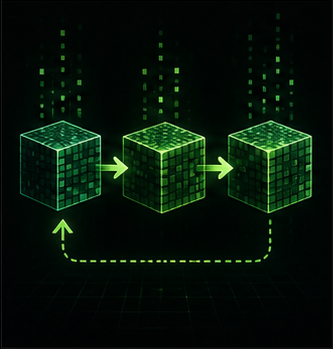

## 🎯 Aim

<div class="alert alert-block alert-info">
<b>Aim:</b> To design and use functions — including recursive functions and lambda expressions — and to understand keyword, default, and variable-length arguments.
</div>

## 🧩 Python Concepts Used

- Function definition & `return`
- Recursion and base cases
- `lambda` expressions
- Keyword arguments, default arguments, `*args`

## Question 1: Verifying From Scratch

### 📋 Problem Statement
> Write a function to find the maximum and minimum from a sequence without using the built-in `max()` and `min()`.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Rather than trust a built-in shortcut, this function proves it can find the maximum and minimum of a sequence by hand — the same self-reliant approach the crew takes when they can't trust the machine's own tools.
</div>

### 🔄 Workflow
```mermaid
flowchart LR
    A["sequence[0] → max, min"] --> B["for each remaining value"]
    B --> C{"value > max?"}
    C -->|Yes| D["max = value"]
    B --> E{"value < min?"}
    E -->|Yes| F["min = value"]
    D --> B
    F --> B
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Seeding `maximum`/`minimum` with the first element (not 0) makes the function correct even for all-negative sequences.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [1]:
def find_max_min(sequence):
    maximum = sequence[0]
    minimum = sequence[0]

    for value in sequence[1:]:
        if value > maximum:
            maximum = value
        if value < minimum:
            minimum = value

    return maximum, minimum

nums = [15, 3, 99, 42, 7]
mx, mn = find_max_min(nums)
print("Maximum:", mx)
print("Minimum:", mn)

Maximum: 99
Minimum: 3


## Question 2: Summing the Cubes

### 📋 Problem Statement
> Write a function that takes a positive integer and returns the sum of cubes of all positive integers smaller than it.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> A function that sums the cubes of every positive integer below a given number — one reusable routine the machine can call with any input.
</div>

### 📐 Formula
$$\sum_{i=1}^{n-1} i^{3}$$

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> The upper bound `range(1, n)` deliberately stops *before* `n`, matching 'smaller than it' from the question.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [2]:
def sum_of_cubes_below(n):
    total = 0
    for i in range(1, n):
        total += i ** 3
    return total

n = 6
print(f"Sum of cubes below {n}:", sum_of_cubes_below(n))

Sum of cubes below 6: 225


## Question 3: The Mirror Hallway

### 📋 Problem Statement
> Write a recursive function to print numbers from 1 to `n` without using any loops.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Recursion is the mirror hallway trick: a function calling a smaller version of itself until it hits a base case and unwinds.
</div>

### 🔄 Workflow
```mermaid
flowchart TD
    A["print_1_to_n(10)"] --> B["print_1_to_n(9)"]
    B --> C["... recurses down to ..."]
    C --> D["print_1_to_n(0) → base case, return"]
    D --> E["unwind: print 1, 2, 3 ... 10"]
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Because the recursive call happens *before* the print, numbers are printed in ascending order on the way back up the call stack, not on the way down.
</div>

### ⚠️ Watch Out
<div class="alert alert-block alert-warning">
<b>Watch Out:</b> Deep recursion in Python is limited by `sys.getrecursionlimit()` (usually 1000) — fine for n=10, but an iterative loop is safer for very large n.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [3]:
def print_1_to_n(n):
    if n == 0:
        return
    print_1_to_n(n - 1)
    print(n, end=" ")

print_1_to_n(10)
print()

1 2 3 4 5 6 7 8 9 10 


## Question 4: Echoing Backward

### 📋 Problem Statement
> Write a recursive function to print the Fibonacci series up to `n` terms.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Fibonacci again, but recursively — each term calling on the two before it, echoing endlessly backward until it bottoms out at 0 and 1.
</div>

### 📐 Formula
$$fib(n) = fib(n-1) + fib(n-2), \quad fib(0)=0,\ fib(1)=1$$

### 🔄 Workflow
```mermaid
flowchart TD
    A["fib(4)"] --> B["fib(3)"]
    A --> C["fib(2)"]
    B --> D["fib(2)"]
    B --> E["fib(1)"]
    D --> F["fib(1)"]
    D --> G["fib(0)"]
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Notice `fib(2)` gets recomputed multiple times — this naive recursive version is O(2ⁿ); memoization would fix the repeated work.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [4]:
def fib(n):
    if n == 0:
        return 0
    if n == 1:
        return 1
    return fib(n - 1) + fib(n - 2)

terms = 8
print("Fibonacci series:")
for i in range(terms):
    print(fib(i), end=" ")
print()

Fibonacci series:
0 1 1 2 3 5 8 13 


## Question 5: The Disposable Subroutine

### 📋 Problem Statement
> Write a lambda function to find the volume of a cone. Formula: `V = (1/3) * pi * r^2 * h`.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> A `lambda` is a program with no name and no ceremony — spun up on the spot to do one job and then gone.
</div>

### 📐 Formula
$$V = \dfrac{1}{3}\pi r^{2} h$$

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> A one-line `lambda` is ideal for a small, throwaway formula that doesn't need a full `def` block.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [5]:
import math

cone_volume = lambda r, h: (1 / 3) * math.pi * r ** 2 * h

print("Volume of cone:", cone_volume(3, 5))

Volume of cone: 47.12388980384689


## Question 6: Two Answers, One Line

### 📋 Problem Statement
> Write a lambda function that returns a tuple of the maximum and minimum from a list.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Another throwaway lambda, returning both the max and min of a list in a single call.
</div>

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Returning a tuple `(max(values), min(values))` lets one lambda hand back two results at once.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [6]:
data = [10, 6, 8, 90, 12, 56]
max_min_tuple = lambda values: (max(values), min(values))

print("Result:", max_min_tuple(data))

Result: (90, 6)


## Question 7: Three Ways to Adapt

### 📋 Problem Statement
> Write functions to demonstrate keyword arguments, default arguments, and variable-length arguments.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Agent Smith's power comes from flexibility — the same routine, called differently every time. This block shows three ways a function can adapt to whatever's thrown at it.
</div>

### 🔄 Workflow
```mermaid
flowchart TD
    A["Function call styles"] --> B["Keyword args: name= value pairs, any order"]
    A --> C["Default args: fallback used if omitted"]
    A --> D["*args: any number of positional values"]
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> `*marks` collects any number of positional arguments into a tuple automatically — no need to know the count in advance.
</div>

### ⚠️ Watch Out
<div class="alert alert-block alert-warning">
<b>Watch Out:</b> Default argument values are evaluated only *once*, at function definition time — using a mutable default like `[]` or `{}` is a classic Python trap that this example correctly avoids by using an immutable string default.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [7]:
# Keyword argument
def student_info(name, age):
    print(f"Name: {name}, Age: {age}")

student_info(age=20, name="Ravi")

# Default argument
def greet(name, message="Welcome to Python Lab"):
    print(f"{name}: {message}")

greet("Riya")
greet("Riya", "Good morning")

# Variable length argument
def total_marks(*marks):
    return sum(marks)

print("Total marks:", total_marks(78, 85, 90, 88, 76))

Name: Ravi, Age: 20
Riya: Welcome to Python Lab
Riya: Good morning
Total marks: 417


## 🌟 Original Extension: Memoized Fibonacci

<div class="alert alert-block alert-info">
<b>💡 Why this extension:</b> Q4's recursive Fibonacci recomputes the same values over and over — fine for small n, painfully slow for large n. This extension applies `functools.lru_cache` to memoize it.
</div>

### 🔧 What It Adds

<div class="alert alert-block alert-success">
<b>New capability:</b> Introduces a decorator (`@lru_cache`) and demonstrates, with `fib_memo(40)`, how memoization turns an exponential-time recursive function into an instant one.
</div>

In [8]:
from functools import lru_cache


@lru_cache(maxsize=None)
def fib_memo(n):
    if n == 0:
        return 0
    if n == 1:
        return 1
    return fib_memo(n - 1) + fib_memo(n - 2)


print("Memoized Fibonacci (first 15 terms):")
print([fib_memo(i) for i in range(15)])
print("fib_memo(40) =", fib_memo(40), "(instant, thanks to caching)")

Memoized Fibonacci (first 15 terms):
[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377]
fib_memo(40) = 102334155 (instant, thanks to caching)


## 📝 Conclusion

<div class="alert alert-block alert-success">
<b>📝 Conclusion:</b> This experiment covered function design, recursion, lambda expressions, and Python's flexible argument-passing styles. Writing the same logic recursively versus iteratively made the trade-offs between clarity and efficiency concrete.
</div>

### 🗺️ Where You Are in the Arc

```mermaid
flowchart LR
    E1["1. Basics"]
    E2["2. Operators"]
    E3["3. Conditionals"]
    E4["4. Loops"]
    E5["5. Strings/Sets"]
    E6["6. Lists/Dict"]
    E7["7. Functions"]
    E8["8. Files/Errors"]
    E9["9. Classes"]
    E10["10. Data Viz"]
    E1 --> E2
    E2 --> E3
    E3 --> E4
    E4 --> E5
    E5 --> E6
    E6 --> E7
    E7 --> E8
    E8 --> E9
    E9 --> E10
    class E7 current;
    classDef current fill:#00ff41,stroke:#003b00,stroke-width:3px,color:#000,font-weight:bold;
```